In [3]:
# First, I'll import all necessary libraries for my Spark ML implementation
import pyspark
from pyspark import SparkContext
from pyspark.sql import Row, SQLContext
from pyspark import SparkFiles
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [4]:

# Setting up my Spark environment - this creates the basic execution context
# that will handle distributed processing
# Check if there is an existing SparkContext

sc = SparkContext()
sqlContext = SQLContext(sc)

# I'm loading the Iris dataset from the provided path
# This dataset contains measurements of different iris species
file_path = "iris.csv"  # Adjust path as needed
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
    # Try alternative paths if needed

# Reading the CSV file using pandas first, then converting to Spark DataFrame
# This two-step approach gives me more flexibility with initial data handling
iris_pandas = pd.read_csv(file_path)
iris_df = sqlContext.createDataFrame(iris_pandas)


your 131072x1 screen size is bogus. expect trouble
25/03/14 12:31:44 WARN Utils: Your hostname, HPCAI13 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/03/14 12:31:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/14 12:31:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
/home/coolmax/anaconda3/envs/pyspark_env/lib/python3.8/site-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [ ]:

# Let's check the schema to understand the data structure
print("Dataset schema:")
iris_df.printSchema()

# I need to convert the text labels to numeric values for machine learning
# StringIndexer handles this encoding automatically
from pyspark.ml.feature import StringIndexer

# Creating an indexer to transform "variety" column to numeric "label" column
label_indexer = StringIndexer(inputCol="variety", outputCol="label")
indexer_model = label_indexer.fit(iris_df)
iris_labeled = indexer_model.transform(iris_df)

# Let's see what numeric values were assigned to each species
print("Label mapping:")
iris_labeled.select("variety", "label").distinct().show()

# Now I'll create a feature vector combining all measurement columns
# This is required by Spark ML algorithms that expect a single features column
from pyspark.ml.feature import VectorAssembler

# Combining the four measurement features into a single vector column
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
iris_features = assembler.transform(iris_labeled)

# Taking a quick look at our prepared dataset
print("First 5 records with features vector:")
iris_features.select("variety", "label", "features").show(5)

# Caching the dataset for faster processing since I'll use it multiple times
iris_features.cache()


Dataset schema:
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- variety: string (nullable = true)



Label mapping:
+----------+-----+
|   variety|label|
+----------+-----+
|    Setosa|  0.0|
|Versicolor|  1.0|
| Virginica|  2.0|
+----------+-----+

First 5 records with features vector:
+-------+-----+-----------------+
|variety|label|         features|
+-------+-----+-----------------+
| Setosa|  0.0|[5.1,3.5,1.4,0.2]|
| Setosa|  0.0|[4.9,3.0,1.4,0.2]|
| Setosa|  0.0|[4.7,3.2,1.3,0.2]|
| Setosa|  0.0|[4.6,3.1,1.5,0.2]|
| Setosa|  0.0|[5.0,3.6,1.4,0.2]|
+-------+-----+-----------------+
only showing top 5 rows



DataFrame[sepal_length: double, sepal_width: double, petal_length: double, petal_width: double, variety: string, label: double, features: vector]

25/03/14 12:32:01 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Training set size: 139 rows
Test set size: 11 rows

--- Decision Tree Classifier ---
Tree depth: 4
Number of nodes: 13
Decision Tree accuracy: 0.8182
Confusion matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    3|
|  1.0|       1.0|    3|
|  2.0|       1.0|    2|
|  2.0|       2.0|    3|
+-----+----------+-----+


--- Random Forest Classifier ---
Random Forest accuracy: 0.8182
Confusion matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    3|
|  1.0|       1.0|    3|
|  2.0|       1.0|    2|
|  2.0|       2.0|    3|
+-----+----------+-----+


=== Gradient Boosted Tree Classifier ===


Gradient Boosted Tree Accuracy: 0.8182
Gradient Boosted Tree Confusion Matrix:


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    3|
|  1.0|       1.0|    3|
|  2.0|       1.0|    2|
|  2.0|       2.0|    3|
+-----+----------+-----+


--- Model Comparison ---


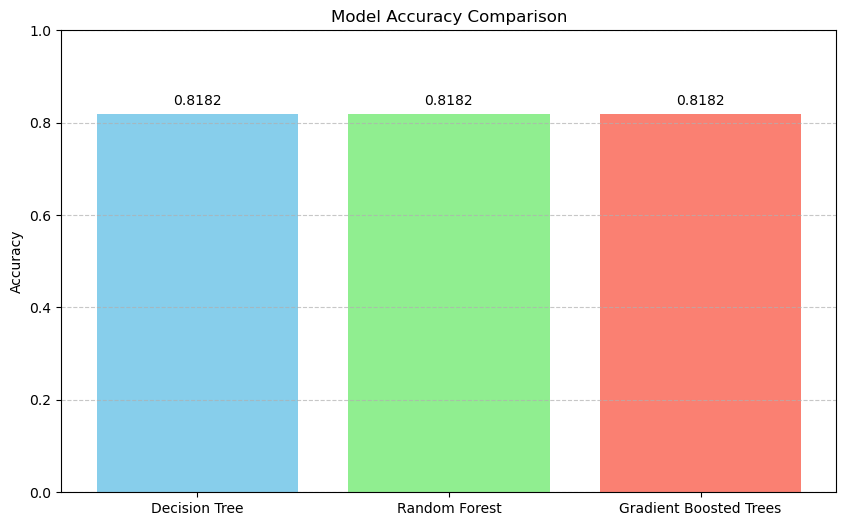

In [7]:

# Splitting data into training (90%) and testing (10%) sets
# The random split uses a seed for reproducibility
train_data, test_data = iris_features.randomSplit([0.9, 0.1], seed=42)
print(f"Training set size: {train_data.count()} rows")
print(f"Test set size: {test_data.count()} rows")

# Now I'll implement three different ML algorithms to compare performance
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Setting up the evaluator for consistent measurement across models
evaluator = MulticlassClassificationEvaluator(
    predictionCol="prediction", 
    labelCol="label", 
    metricName="accuracy"
)

# 1. Decision Tree - A simple but intuitive model
print("\n--- Decision Tree Classifier ---")
dt_classifier = DecisionTreeClassifier(
    maxDepth=4,          # Preventing overfitting by limiting tree depth
    labelCol="label",    # Target variable
    featuresCol="features"  # Input features
)

# Training the decision tree model
dt_model = dt_classifier.fit(train_data)
print(f"Tree depth: {dt_model.depth}")
print(f"Number of nodes: {dt_model.numNodes}")

# Making predictions on test data
dt_predictions = dt_model.transform(test_data)

# Evaluating accuracy
dt_accuracy = evaluator.evaluate(dt_predictions)
print(f"Decision Tree accuracy: {dt_accuracy:.4f}")

# Generating confusion matrix to analyze prediction patterns
print("Confusion matrix:")
dt_predictions.groupBy("label", "prediction").count().show()

# 2. Random Forest - An ensemble of decision trees
print("\n--- Random Forest Classifier ---")
rf_classifier = RandomForestClassifier(
    numTrees=10,        # Using 10 trees in the ensemble
    labelCol="label", 
    featuresCol="features"
)

# Training the random forest model
rf_model = rf_classifier.fit(train_data)

# Making predictions and evaluating
rf_predictions = rf_model.transform(test_data)
rf_accuracy = evaluator.evaluate(rf_predictions)
print(f"Random Forest accuracy: {rf_accuracy:.4f}")

# Confusion matrix for random forest
print("Confusion matrix:")
rf_predictions.groupBy("label", "prediction").count().show()

# 3. Gradient Boosted Trees - A sequential ensemble approach
# GRADIENT BOOSTED TREE CLASSIFIER with OneVsRest for multi-class handling
print("\n=== Gradient Boosted Tree Classifier ===")
# Create base GBT classifier 
gbt = GBTClassifier(maxIter=10)
# Wrap with OneVsRest for multi-class classification
ovr = OneVsRest(classifier=gbt, labelCol="label", featuresCol="features")
# Train the model
gbt_model = ovr.fit(train_data)

# Make predictions
predictions_gbt = gbt_model.transform(test_data)
# Evaluate accuracy
accuracy_gbt = evaluator.evaluate(predictions_gbt)
print(f"Gradient Boosted Tree Accuracy: {accuracy_gbt:.4f}")

# Display confusion matrix
print("Gradient Boosted Tree Confusion Matrix:")
predictions_gbt.groupBy("label", "prediction").count().show()

# Comparing all model accuracies
print("\n--- Model Comparison ---")
models = ["Decision Tree", "Random Forest", "Gradient Boosted Trees"]
accuracies = [dt_accuracy, rf_accuracy, accuracy_gbt]

# Creating a simple bar chart to visualize the comparison
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim([0, 1])  # Setting y-axis from 0 to 1 for proper perspective
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, acc in enumerate(accuracies):
    plt.text(i, acc+0.02, f'{acc:.4f}', ha='center')
plt.show()


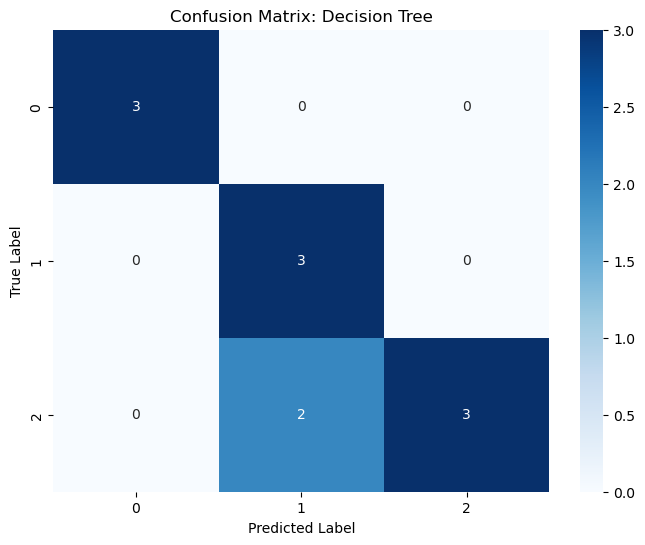

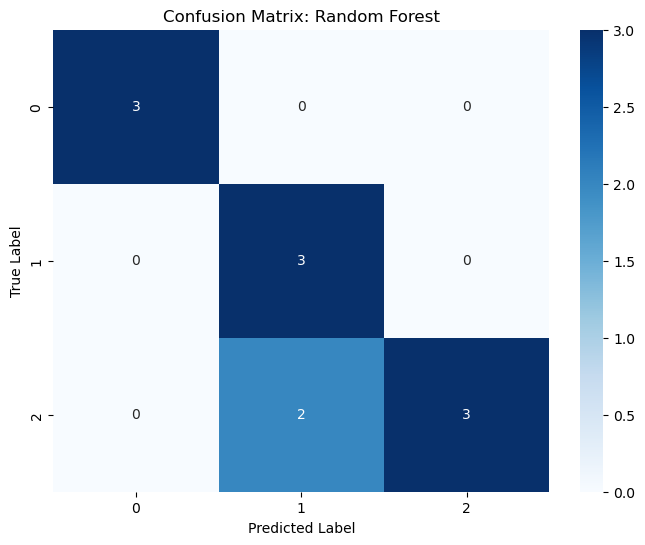

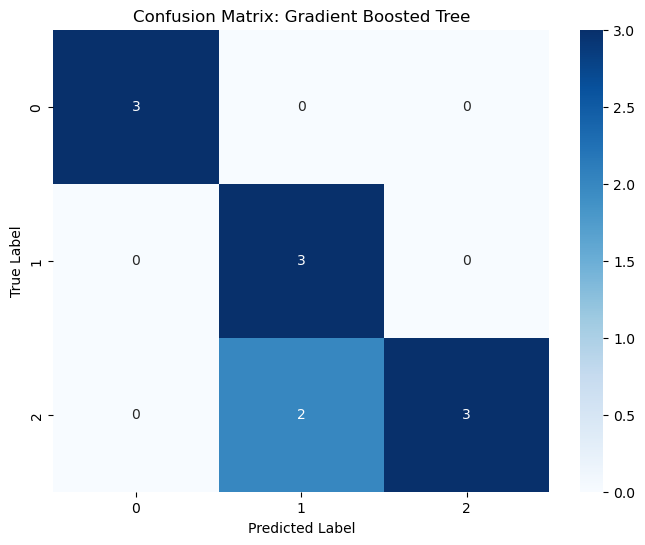

In [11]:
# Visualize confusion matrices for better comparison
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(predictions, title):
    y_true = [float(row['label']) for row in predictions.select("label").collect()]
    y_pred = [float(row['prediction']) for row in predictions.select("prediction").collect()]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Create visualizations for each model
plot_confusion_matrix(dt_predictions, "Decision Tree")
plot_confusion_matrix(rf_predictions, "Random Forest")
plot_confusion_matrix(predictions_gbt, "Gradient Boosted Tree")


=== Model Comparison ===


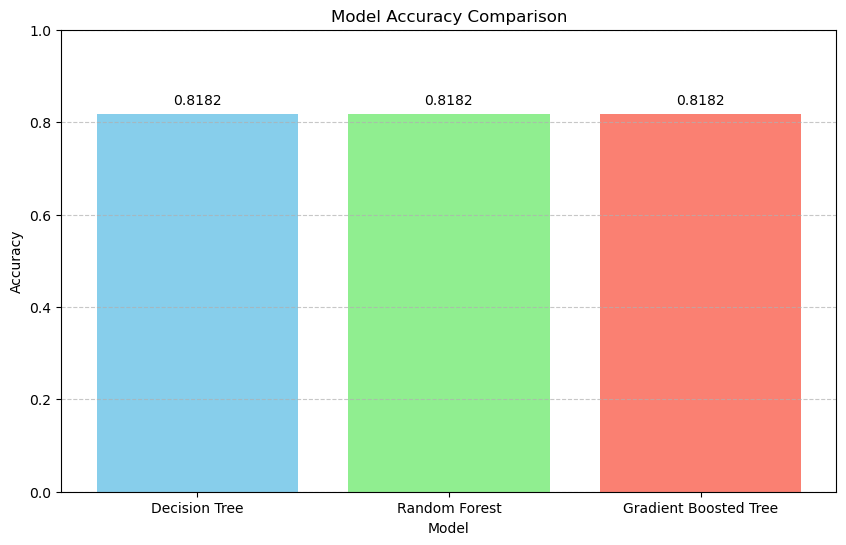

Decision Tree: 0.8182
Random Forest: 0.8182
Gradient Boosted Tree: 0.8182


In [13]:
# COMPARE MODEL ACCURACIES with visualization
print("\n=== Model Comparison ===")
models = ["Decision Tree", "Random Forest", "Gradient Boosted Tree"]
accuracies = [dt_accuracy, rf_accuracy, accuracy_gbt]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print numerical comparison for reference
for model, acc in zip(models, accuracies):
    print(f"{model}: {acc:.4f}")

In [14]:

# Finally, cleaning up Spark context
# This is important to release resources when the job is done
sc.stop()